<a href="https://colab.research.google.com/github/ThiagoBrandaorj/Machine_learning/blob/main/C%C3%B3pia_de_04_Classifica%C3%A7%C3%A3o_de_Atividades_Humanas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DESAFIO 04**

# **Classificação de Atividades Humanas**

Como nossos modelos de machine learning rasa lidam com problemas compostos por muitas variáveis? Vamos avaliar isso em uma base com mais de 550 variáveis!

## **O problema**

O objetivo é construir e treinar um modelo de ML rasa para classificar com precisão a atividade física que uma pessoa está realizando com base nos dados brutos de sensores de um smartphone (acelerômetro e giroscópio).

**Pontos de atenção:**

  * **Alta Dimensionalidade:** o conjunto de dados possui muitas variáveis, o que aumenta consideravelmente o risco de overfitting. Um modelo simples não conseguirá aprender os padrões relevantes e normalmente apresentará um desempenho ruim em dados não vistos.
  * **Sutileza dos Padrões:** as diferenças entre os sinais dos sensores para atividades como "Sentado" (***SITTING***) e "Parado" (***STANDING***) são muito sutis, exigindo que a rede aprenda representações complexas e não-lineares.
  * **Mantenham a cardinalidade da variável alvo:** nesta tarefa vocês não podem agregar classes da variável alvo, ou seja, deverão manter o problema com cardinalidade igual a seis.

## **O Conjunto de Dados**

Utilizaremos o dataset [
***"Human Activity Recognition Using Smartphones"***](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones). Dados e informações podem ser encontrados no link.

O dataset já está dividido em conjuntos de treino e teste e todos devem respeitar esta divisão. As seis classes (atividades) da variável alvo a serem classificadas são:

1.  WALKING
2.  WALKING\_UPSTAIRS
3.  WALKING\_DOWNSTAIRS
4.  SITTING
5.  STANDING
6.  LAYING


## **TAREFA**

Deverá ser utilizado um modelo de machine learning rasa, a escolha do grupo, para prever uma das seis classes (atividades) da variável alvo.

O grupo deverá fazer todas as etapas necessárias tanto na avaliação dos dados disponíveis quanto na preparação necessária para execução do modelo. Todas as etapas devem ser documentadas e as escolhas justificadas.

A performance do modelo deverá ser avaliada por métricas e curvas, ROC e/ou Precision-Recall, de acordo com a necessidade.

Os grupos apresentarão suas soluções a partir do próprio Colab, que deverá estar bem organizado e bem documentado, incluindo as principais escolhas, desafios encontrados e resultados.  

A apresentação dos grupos será feita em sala, no dia 26/03/2025. Cada apresentação deverá durar no máximo 15 minutos e a entrega dos Colabs (via compartilhamento) será feita no próprio dia da apresentação, por e-mail, para (cassius.figueiredo@professores.ibmec.edu.br).


# 1 - EDA

In [ ]:
!pip install -q imbalanced-learn shap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import random
import sys
import platform
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

def show_versions():
    import sklearn, scipy
    vers = {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scipy": scipy.__version__,
        "sklearn": sklearn.__version__,
    }
    try:
        import imblearn
        vers["imblearn"] = imblearn.__version__
    except Exception:
        vers["imblearn"] = "not installed"
    try:
        import shap
        vers["shap"] = shap.__version__
    except Exception:
        vers["shap"] = "not installed"
    return vers

VERSIONS = show_versions()
VERSIONS

{'python': '3.12.13',
 'platform': 'Linux-6.6.113+-x86_64-with-glibc2.35',
 'numpy': '2.0.2',
 'pandas': '2.2.2',
 'scipy': '1.16.3',
 'sklearn': '1.6.1',
 'imblearn': '0.14.1',
 'shap': '0.51.0'}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Verificar se a pasta está no local correto
import os

# Caminho para a pasta UCI HAR Dataset
# Ajuste o caminho conforme onde a pasta está no seu Drive
caminho_base = '/content/drive/My Drive/UCI HAR Dataset/UCI HAR Dataset'

# Verificar se a pasta existe
if os.path.exists(caminho_base):
    print(f"Pasta encontrada: {caminho_base}")
    print("Arquivos e subpastas:")
    print(os.listdir(caminho_base))
else:
    print(f"Pasta não encontrada em: {caminho_base}")
    print("Verifique o caminho exato da pasta no seu Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pasta encontrada: /content/drive/My Drive/UCI HAR Dataset/UCI HAR Dataset
Arquivos e subpastas:
['.DS_Store', 'features_info.txt', 'features.txt', 'README.txt', 'activity_labels.txt', 'train', 'test']


In [ ]:
LABELS = {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
}

SIGNALS = ["body_acc_x_", "body_acc_y_", "body_acc_z_",
           "body_gyro_x_", "body_gyro_y_", "body_gyro_z_",
           "total_acc_x_", "total_acc_y_", "total_acc_z_"]

In [ ]:
# ── 1. Carregar dados ──────────────────────────────────────────────────────────
# Carregar dados de treino
X_train = pd.read_csv(f'{caminho_base}/train/X_train.txt', sep='\s+', header=None)
y_train = pd.read_csv(f'{caminho_base}/train/y_train.txt', sep='\s+', header=None)

# Carregar dados de teste
X_test = pd.read_csv(f'{caminho_base}/test/X_test.txt', sep='\s+', header=None)
y_test = pd.read_csv(f'{caminho_base}/test/y_test.txt', sep='\s+', header=None)

# ── 2. Nomear colunas com os nomes reais das features ─────────────────────────
features = pd.read_csv(f'{caminho_base}/features.txt', sep='\s+', header=None)
X_train.columns = features[1]
X_test.columns = features[1]

# Verificar se carregou corretamente
print(f"Shape do X_train: {X_train.shape}")
print(f"Shape do y_train: {y_train.shape}")
print(f"Shape do X_test: {X_test.shape}")
print(f"Shape do y_test: {y_test.shape}")

Shape do X_train: (7352, 561)
Shape do y_train: (7352, 1)
Shape do X_test: (2947, 561)
Shape do y_test: (2947, 1)


In [ ]:
X_train.head()

1,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [ ]:
X_train.duplicated().sum()

np.int64(0)

In [ ]:
X_test.duplicated().sum()

np.int64(0)

In [ ]:
print(f"Linhas com NA: {X_train.isna().any(axis=0).sum()}")
colunas_com_na = X_train.columns[X_train.isna().any()].tolist()
for i in colunas_com_na:
  print()

Linhas com NA: 0


**Como podemos perceber além dos dados já virem separados em treino e teste, os dados de todas as variáveis vem escalonados, portanto toda a etapa da EDA e pré-processamento não se faz necessária nesse caso**

**Devido a enorme dimensionalidade dos dados que contém 561 variáveis, iremos buscar formas de reduzir essa dimensionalidade antes de começarmos a modelar**

**Iremos tentar aplicar alguns algoritimos de redução de dimensionalidade, como mencioando em [1] para reduzir a dimensionalidade**

**Como no artigo de referência iremos aplicar o K-means para reduzir a dimensionalidade do problema na matriz transpopsta dos dados ou seja aplicaremos o algoritimo k-means sobre as variáveis e não sobre os registros dessa fo**

**Ou seja cada feauture vira uma amostra para o algoritimo**

## k-means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

# ── 1. Aplicar K-means nas FEATURES (transposta) ──────────────────────────────
k = 70  # Melhor k encontrado no artigo para o HAR dataset

kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
kmeans.fit(X_train.T)  # Transpõe: cada feature vira um registro para o K-means

KMeans(n_clusters=70, random_state=42)

In [ ]:
# ── 2. Extrair centroides como novo conjunto de features ──────────────────────
# Os centroides têm shape (k, n_amostras) → transpor para (n_amostras, k)
X_train_reduzido = kmeans.cluster_centers_.T
X_test_reduzido  = kmeans.cluster_centers_.T

In [ ]:
# ── 3. Projetar X_test corretamente ───────────────────────────────────────────
# Para o teste, precisamos atribuir cada feature ao cluster mais próximo
# e usar o centroide correspondente
labels = kmeans.labels_  # cluster de cada feature (0 a k-1)

In [ ]:
# Reduzir X_test usando os mesmos clusters
X_test_reduzido = np.array([
    X_test.values[:, labels == c].mean(axis=1)
    for c in range(k)
]).T  # shape: (n_amostras_teste, k)

In [ ]:
# Reduzir X_train também da mesma forma (consistente)
X_train_reduzido = np.array([
    X_train.values[:, labels == c].mean(axis=1)
    for c in range(k)
]).T  # shape: (n_amostras_treino, k)

In [ ]:
print(f"Shape original:  {X_train.shape}")
print(f"Shape reduzido:  {X_train_reduzido.shape}")

Shape original:  (7352, 561)
Shape reduzido:  (7352, 70)


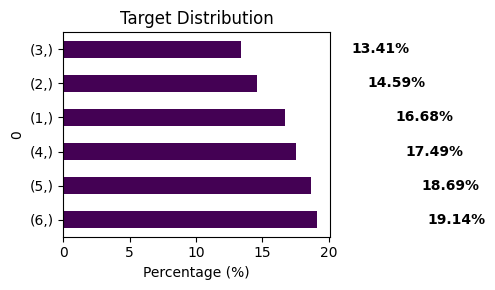

In [ ]:
cholcheck_counts = y_train.value_counts(normalize=True) * 100

ax = cholcheck_counts.plot(kind='barh', colormap='viridis', figsize=(6, 3))

for bar, val in zip(ax.patches, cholcheck_counts.values):
    ax.text(bar.get_width() + 10.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', ha='center', color='black', fontweight='bold')

ax.set_title('Target Distribution')
ax.set_xlabel('Percentage (%)')
plt.tight_layout()
plt.show()

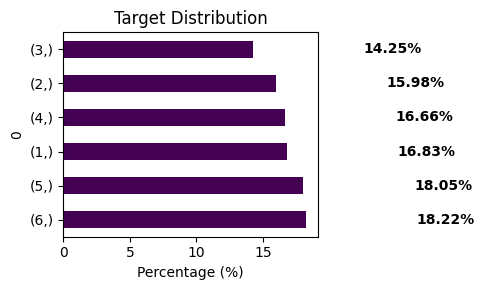

In [ ]:
cholcheck_counts = y_test.value_counts(normalize=True) * 100

ax = cholcheck_counts.plot(kind='barh', colormap='viridis', figsize=(6, 3))

for bar, val in zip(ax.patches, cholcheck_counts.values):
    ax.text(bar.get_width() + 10.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', ha='center', color='black', fontweight='bold')

ax.set_title('Target Distribution')
ax.set_xlabel('Percentage (%)')
plt.tight_layout()
plt.show()

## modelagem com redução usando k-means


In [ ]:
k_means_treino = {}
k_means_teste = {}

In [ ]:
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

### Naive Bayes

In [ ]:
# ── 4. Treinar classificador e avaliar ────────────────────────────────────────
y_train_flat = y_train.values.ravel()
y_test_flat  = y_test.values.ravel()

clf = GaussianNB()
clf.fit(X_train_reduzido, y_train_flat)

y_pred_train = clf.predict(X_train_reduzido)
y_pred_test  = clf.predict(X_test_reduzido)

# ── Resultados em Treino ───────────────────────────────────────────────────────
print("=" * 55)
print(f"TREINO  (k={k})")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_train_flat, y_pred_train):.4f}")
k_means_treino["Naive_bayes"] = round(accuracy_score(y_train_flat, y_pred_train),2)
print(classification_report(y_train_flat, y_pred_train))

# ── Resultados em Teste ────────────────────────────────────────────────────────
print("=" * 55)
print(f"TESTE  (k={k})")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_test_flat, y_pred_test):.4f}")
k_means_teste["Naive_bayes"] = round(accuracy_score(y_test_flat, y_pred_test),2)
print(classification_report(y_test_flat, y_pred_test))

TREINO  (k=70)
Acurácia: 0.8663
              precision    recall  f1-score   support

           1       0.94      0.84      0.89      1226
           2       0.80      0.92      0.85      1073
           3       0.84      0.84      0.84       986
           4       0.90      0.67      0.77      1286
           5       0.76      0.92      0.83      1374
           6       0.99      1.00      0.99      1407

    accuracy                           0.87      7352
   macro avg       0.87      0.86      0.86      7352
weighted avg       0.87      0.87      0.87      7352

TESTE  (k=70)
Acurácia: 0.8534
              precision    recall  f1-score   support

           1       0.83      0.92      0.88       496
           2       0.85      0.95      0.90       471
           3       0.87      0.67      0.76       420
           4       0.93      0.59      0.72       491
           5       0.72      0.94      0.81       532
           6       1.00      1.00      1.00       537

    accuracy  

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=10,max_depth=6, random_state=42, n_jobs=-1)
clf.fit(X_train_reduzido, y_train_flat)
y_pred_train = clf.predict(X_train_reduzido)
y_pred_test  = clf.predict(X_test_reduzido)
# ── Resultados em Treino ───────────────────────────────────────────────────────
print("=" * 55)
print(f"RANDOM FOREST — TREINO  (k={k})")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_train_flat, y_pred_train):.4f}")
k_means_treino["Random Forest"] = round(accuracy_score(y_train_flat, y_pred_train),2)
print(classification_report(y_train_flat, y_pred_train))

# ── Resultados em Teste ────────────────────────────────────────────────────────
print("=" * 55)
print(f"RANDOM FOREST — TESTE  (k={k})")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_test_flat, y_pred_test):.4f}")
k_means_teste["Random Forest"] = round(accuracy_score(y_test_flat, y_pred_test),2)
print(classification_report(y_test_flat, y_pred_test))

RANDOM FOREST — TREINO  (k=70)
Acurácia: 0.9340
              precision    recall  f1-score   support

           1       0.94      0.94      0.94      1226
           2       0.93      0.93      0.93      1073
           3       0.93      0.95      0.94       986
           4       0.90      0.89      0.89      1286
           5       0.90      0.91      0.90      1374
           6       1.00      1.00      1.00      1407

    accuracy                           0.93      7352
   macro avg       0.93      0.93      0.93      7352
weighted avg       0.93      0.93      0.93      7352

RANDOM FOREST — TESTE  (k=70)
Acurácia: 0.8694
              precision    recall  f1-score   support

           1       0.78      0.94      0.85       496
           2       0.89      0.81      0.85       471
           3       0.90      0.79      0.84       420
           4       0.85      0.79      0.82       491
           5       0.82      0.86      0.84       532
           6       1.00      1.00    

### Regressão Softmax

In [ ]:
from sklearn.linear_model import LogisticRegression

softmax_regressor = LogisticRegression(C=3,random_state=42,max_iter=100)
softmax_regressor.fit(X_train_reduzido,y_train_flat)
y_pred_train = softmax_regressor.predict(X_train_reduzido)
y_pred_test  = softmax_regressor.predict(X_test_reduzido)

# ── Resultados em Treino ───────────────────────────────────────────────────────
print("=" * 55)
print(f"SOFTMAX (Logistic Regression) — TREINO  (k={k})")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_train_flat, y_pred_train):.4f}")
k_means_treino["softmax"] = round(accuracy_score(y_train_flat, y_pred_train),2)
print(classification_report(y_train_flat, y_pred_train))

# ── Resultados em Teste ────────────────────────────────────────────────────────
print("=" * 55)
print(f"SOFTMAX (Logistic Regression) — TESTE  (k={k})")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_test_flat, y_pred_test):.4f}")
k_means_teste["softmax"] = round(accuracy_score(y_test_flat, y_pred_test),2)
print(classification_report(y_test_flat, y_pred_test))

SOFTMAX (Logistic Regression) — TREINO  (k=70)
Acurácia: 0.9635
              precision    recall  f1-score   support

           1       0.99      0.99      0.99      1226
           2       0.99      0.99      0.99      1073
           3       0.99      0.99      0.99       986
           4       0.91      0.91      0.91      1286
           5       0.92      0.92      0.92      1374
           6       1.00      1.00      1.00      1407

    accuracy                           0.96      7352
   macro avg       0.97      0.97      0.97      7352
weighted avg       0.96      0.96      0.96      7352

SOFTMAX (Logistic Regression) — TESTE  (k=70)
Acurácia: 0.9141
              precision    recall  f1-score   support

           1       0.89      0.98      0.94       496
           2       0.93      0.90      0.91       471
           3       0.96      0.89      0.93       420
           4       0.89      0.80      0.84       491
           5       0.83      0.90      0.87       532
     

### SVM

In [ ]:
from sklearn.svm import SVC

clf = SVC(
    kernel='rbf',        # Kernel mais usado para dados não-lineares
    C=1.0,               # Penalização por erro — maior C = menos tolerante
    gamma='scale',       # Escala automática baseada nas features
    random_state=42
)
clf.fit(X_train_reduzido, y_train_flat)

# ── Predições ──────────────────────────────────────────────────────────────────
y_pred_train = clf.predict(X_train_reduzido)
y_pred_test  = clf.predict(X_test_reduzido)

# ── Resultados em Treino ───────────────────────────────────────────────────────
print("=" * 55)
print(f"SVM (RBF) — TREINO  (k={k})")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_train_flat, y_pred_train):.4f}")
k_means_treino["svm"] = round(accuracy_score(y_train_flat, y_pred_train),2)
print(classification_report(y_train_flat, y_pred_train))

# ── Resultados em Teste ────────────────────────────────────────────────────────
print("=" * 55)
print(f"SVM (RBF) — TESTE  (k={k})")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_test_flat, y_pred_test):.4f}")
k_means_teste["svm"] = round(accuracy_score(y_test_flat, y_pred_test),2)
print(classification_report(y_test_flat, y_pred_test))

SVM (RBF) — TREINO  (k=70)
Acurácia: 0.9637
              precision    recall  f1-score   support

           1       0.99      0.99      0.99      1226
           2       0.99      0.98      0.98      1073
           3       0.98      0.99      0.98       986
           4       0.93      0.90      0.91      1286
           5       0.91      0.94      0.92      1374
           6       1.00      1.00      1.00      1407

    accuracy                           0.96      7352
   macro avg       0.97      0.96      0.97      7352
weighted avg       0.96      0.96      0.96      7352

SVM (RBF) — TESTE  (k=70)
Acurácia: 0.9220
              precision    recall  f1-score   support

           1       0.91      0.99      0.95       496
           2       0.93      0.90      0.91       471
           3       0.96      0.90      0.92       420
           4       0.90      0.82      0.86       491
           5       0.85      0.92      0.88       532
           6       1.00      1.00      1.00  

### XGboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost exige classes começando em 0 (ex: 0,1,2,3,4,5)
# O HAR dataset tem classes 1-6, então precisamos encodar
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_flat)
y_test_enc  = le.transform(y_test_flat)

clf = XGBClassifier(
    n_estimators=100,        # Número de árvores
    max_depth=4,             # Profundidade máxima de cada árvore
    learning_rate=0.01,       # Taxa de aprendizado
    subsample=0.8,           # Fração de amostras por árvore
    colsample_bytree=0.8,    # Fração de features por árvore
    use_label_encoder=False,
    eval_metric='mlogloss',  # Métrica para multiclasse
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train_reduzido, y_train_enc)

# ── Predições (revertendo o encoding para os rótulos originais) ────────────────
y_pred_train = le.inverse_transform(clf.predict(X_train_reduzido))
y_pred_test  = le.inverse_transform(clf.predict(X_test_reduzido))

# ── Resultados em Treino ───────────────────────────────────────────────────────
print("=" * 55)
print(f"XGBOOST — TREINO  (k={k})")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_train_flat, y_pred_train):.4f}")
k_means_treino["xgboost"] = round(accuracy_score(y_train_flat, y_pred_train),2)
print(classification_report(y_train_flat, y_pred_train))

# ── Resultados em Teste ────────────────────────────────────────────────────────
print("=" * 55)
print(f"XGBOOST — TESTE  (k={k})")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_test_flat, y_pred_test):.4f}")
k_means_teste["xgboost"] = round(accuracy_score(y_test_flat, y_pred_test),2)
print(classification_report(y_test_flat, y_pred_test))

XGBOOST — TREINO  (k=70)
Acurácia: 0.9539
              precision    recall  f1-score   support

           1       0.97      0.98      0.98      1226
           2       0.97      0.97      0.97      1073
           3       0.98      0.98      0.98       986
           4       0.89      0.91      0.90      1286
           5       0.92      0.89      0.90      1374
           6       1.00      1.00      1.00      1407

    accuracy                           0.95      7352
   macro avg       0.96      0.96      0.96      7352
weighted avg       0.95      0.95      0.95      7352

XGBOOST — TESTE  (k=70)
Acurácia: 0.8704
              precision    recall  f1-score   support

           1       0.80      0.96      0.88       496
           2       0.88      0.83      0.85       471
           3       0.96      0.79      0.87       420
           4       0.81      0.79      0.80       491
           5       0.81      0.83      0.82       532
           6       0.99      1.00      1.00      

## modelagem sem nenhuma redução

In [ ]:
original_treino = {}
original_teste = {}

### Naive Bayes

In [ ]:
# ── 4. Treinar classificador e avaliar ────────────────────────────────────────
y_train_flat = y_train.values.ravel()
y_test_flat  = y_test.values.ravel()

clf = GaussianNB()
clf.fit(X_train, y_train_flat)

y_pred_train = clf.predict(X_train)
y_pred_test  = clf.predict(X_test)

# ── Resultados em Treino ───────────────────────────────────────────────────────
print("=" * 55)
print(f"TREINO com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_train_flat, y_pred_train):.4f}")
original_treino["Naive_bayes"] = round(accuracy_score(y_train_flat, y_pred_train),2)
print(classification_report(y_train_flat, y_pred_train))

# ── Resultados em Teste ────────────────────────────────────────────────────────
print("=" * 55)
print(f"TESTE  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_test_flat, y_pred_test):.4f}")
original_teste["Naive_bayes"] = round(accuracy_score(y_test_flat, y_pred_test),2)
print(classification_report(y_test_flat, y_pred_test))

TREINO com dados originais
Acurácia: 0.7463
              precision    recall  f1-score   support

           1       0.94      0.73      0.82      1226
           2       0.70      0.90      0.79      1073
           3       0.79      0.79      0.79       986
           4       0.53      0.81      0.64      1286
           5       0.84      0.80      0.82      1374
           6       0.97      0.50      0.66      1407

    accuracy                           0.75      7352
   macro avg       0.79      0.76      0.75      7352
weighted avg       0.80      0.75      0.75      7352

TESTE  com dados originais
Acurácia: 0.7703
              precision    recall  f1-score   support

           1       0.82      0.84      0.83       496
           2       0.76      0.96      0.84       471
           3       0.83      0.61      0.70       420
           4       0.58      0.75      0.65       491
           5       0.80      0.86      0.83       532
           6       0.96      0.60      0.74 

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=10,max_depth=6, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train_flat)
y_pred_train = clf.predict(X_train)
y_pred_test  = clf.predict(X_test)
# ── Resultados em Treino ───────────────────────────────────────────────────────
print("=" * 55)
print(f"RANDOM FOREST — TREINO  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_train_flat, y_pred_train):.4f}")
original_treino["Random Forest"] = round(accuracy_score(y_train_flat, y_pred_train),2)
print(classification_report(y_train_flat, y_pred_train))

# ── Resultados em Teste ────────────────────────────────────────────────────────
print("=" * 55)
print(f"RANDOM FOREST — TESTE  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_test_flat, y_pred_test):.4f}")
original_teste["Random Forest"] = round(accuracy_score(y_test_flat, y_pred_test),2)
print(classification_report(y_test_flat, y_pred_test))

RANDOM FOREST — TREINO  com dados originais
Acurácia: 0.9600
              precision    recall  f1-score   support

           1       0.96      0.97      0.97      1226
           2       0.96      0.97      0.96      1073
           3       0.97      0.95      0.96       986
           4       0.94      0.92      0.93      1286
           5       0.93      0.95      0.94      1374
           6       1.00      1.00      1.00      1407

    accuracy                           0.96      7352
   macro avg       0.96      0.96      0.96      7352
weighted avg       0.96      0.96      0.96      7352

RANDOM FOREST — TESTE  com dados originais
Acurácia: 0.8914
              precision    recall  f1-score   support

           1       0.81      0.95      0.87       496
           2       0.87      0.87      0.87       471
           3       0.95      0.76      0.84       420
           4       0.89      0.85      0.87       491
           5       0.87      0.90      0.88       532
           

### Regressão Softmax

In [ ]:
from sklearn.linear_model import LogisticRegression

softmax_regressor = LogisticRegression(C=3,random_state=42,max_iter=100)
softmax_regressor.fit(X_train,y_train_flat)
y_pred_train = softmax_regressor.predict(X_train)
y_pred_test  = softmax_regressor.predict(X_test)

# ── Resultados em Treino ───────────────────────────────────────────────────────
print("=" * 55)
print(f"SOFTMAX (Logistic Regression) — TREINO  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_train_flat, y_pred_train):.4f}")
original_treino["softmax"] = round(accuracy_score(y_train_flat, y_pred_train),2)
print(classification_report(y_train_flat, y_pred_train))

# ── Resultados em Teste ────────────────────────────────────────────────────────
print("=" * 55)
print(f"SOFTMAX (Logistic Regression) — TESTE  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_test_flat, y_pred_test):.4f}")
original_teste["softmax"] = round(accuracy_score(y_test_flat, y_pred_test),2)
print(classification_report(y_test_flat, y_pred_test))

SOFTMAX (Logistic Regression) — TREINO  com dados originais
Acurácia: 0.9921
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1226
           2       1.00      1.00      1.00      1073
           3       1.00      1.00      1.00       986
           4       0.98      0.98      0.98      1286
           5       0.98      0.98      0.98      1374
           6       1.00      1.00      1.00      1407

    accuracy                           0.99      7352
   macro avg       0.99      0.99      0.99      7352
weighted avg       0.99      0.99      0.99      7352

SOFTMAX (Logistic Regression) — TESTE  com dados originais
Acurácia: 0.9603
              precision    recall  f1-score   support

           1       0.95      1.00      0.97       496
           2       0.97      0.95      0.96       471
           3       1.00      0.96      0.98       420
           4       0.97      0.87      0.92       491
           5       0.90      0.98

### SVM

In [ ]:
from sklearn.svm import SVC

clf = SVC(
    kernel='rbf',        # Kernel mais usado para dados não-lineares
    C=1.0,               # Penalização por erro — maior C = menos tolerante
    gamma='scale',       # Escala automática baseada nas features
    random_state=42
)
clf.fit(X_train, y_train_flat)

# ── Predições ──────────────────────────────────────────────────────────────────
y_pred_train = clf.predict(X_train)
y_pred_test  = clf.predict(X_test)

# ── Resultados em Treino ───────────────────────────────────────────────────────
print("=" * 55)
print(f"SVM (RBF) — TREINO  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_train_flat, y_pred_train):.4f}")
original_treino["svm"] = round(accuracy_score(y_train_flat, y_pred_train),2)
print(classification_report(y_train_flat, y_pred_train))

# ── Resultados em Teste ────────────────────────────────────────────────────────
print("=" * 55)
print(f"SVM (RBF) — TESTE  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_test_flat, y_pred_test):.4f}")
original_teste["svm"] = round(accuracy_score(y_test_flat, y_pred_test),2)
print(classification_report(y_test_flat, y_pred_test))

SVM (RBF) — TREINO  com dados originais
Acurácia: 0.9791
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1226
           2       1.00      1.00      1.00      1073
           3       1.00      1.00      1.00       986
           4       0.94      0.94      0.94      1286
           5       0.95      0.95      0.95      1374
           6       1.00      1.00      1.00      1407

    accuracy                           0.98      7352
   macro avg       0.98      0.98      0.98      7352
weighted avg       0.98      0.98      0.98      7352

SVM (RBF) — TESTE  com dados originais
Acurácia: 0.9505
              precision    recall  f1-score   support

           1       0.94      0.98      0.96       496
           2       0.93      0.96      0.94       471
           3       0.99      0.91      0.95       420
           4       0.94      0.89      0.91       491
           5       0.91      0.95      0.93       532
           6       

### XGboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost exige classes começando em 0 (ex: 0,1,2,3,4,5)
# O HAR dataset tem classes 1-6, então precisamos encodar
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_flat)
y_test_enc  = le.transform(y_test_flat)

clf = XGBClassifier(
    n_estimators=100,        # Número de árvores
    max_depth=4,             # Profundidade máxima de cada árvore
    learning_rate=0.01,       # Taxa de aprendizado
    subsample=0.8,           # Fração de amostras por árvore
    colsample_bytree=0.8,    # Fração de features por árvore
    use_label_encoder=False,
    eval_metric='mlogloss',  # Métrica para multiclasse
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train_enc)

# ── Predições (revertendo o encoding para os rótulos originais) ────────────────
y_pred_train = le.inverse_transform(clf.predict(X_train))
y_pred_test  = le.inverse_transform(clf.predict(X_test))

# ── Resultados em Treino ───────────────────────────────────────────────────────
print("=" * 55)
print(f"XGBOOST — TREINO  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_train_flat, y_pred_train):.4f}")
original_treino["xgboost"] = round(accuracy_score(y_train_flat, y_pred_train),2)
print(classification_report(y_train_flat, y_pred_train))

# ── Resultados em Teste ────────────────────────────────────────────────────────
print("=" * 55)
print(f"XGBOOST — TESTE  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_test_flat, y_pred_test):.4f}")
original_teste["xgboost"] = round(accuracy_score(y_test_flat, y_pred_test),2)
print(classification_report(y_test_flat, y_pred_test))

XGBOOST — TREINO  com dados originais
Acurácia: 0.9684
              precision    recall  f1-score   support

           1       0.99      0.99      0.99      1226
           2       0.99      0.99      0.99      1073
           3       0.99      0.99      0.99       986
           4       0.92      0.93      0.92      1286
           5       0.94      0.92      0.93      1374
           6       1.00      1.00      1.00      1407

    accuracy                           0.97      7352
   macro avg       0.97      0.97      0.97      7352
weighted avg       0.97      0.97      0.97      7352

XGBOOST — TESTE  com dados originais
Acurácia: 0.8955
              precision    recall  f1-score   support

           1       0.87      0.96      0.91       496
           2       0.91      0.88      0.89       471
           3       0.94      0.88      0.91       420
           4       0.84      0.79      0.81       491
           5       0.82      0.86      0.84       532
           6       1.00

## Modelagem com PCA

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1
d

np.int64(3)

**Porntanto usaremos 67 variaveis, elas explicam 95% da variância dos dados, dessa forma a maior parte da variância dos dados estarao no modelo**

In [ ]:
pca = PCA(n_components=d)
X_reduced_pca = pca.fit_transform(X_train)
X_test_reduced_pca = pca.transform(X_test)
pca_treino = {}
pca_teste = {}

### Naive Bayes

In [ ]:
# ── 4. Treinar classificador e avaliar ────────────────────────────────────────
y_train_flat = y_train.values.ravel()
y_test_flat  = y_test.values.ravel()

clf = GaussianNB()
clf.fit(X_reduced_pca, y_train_flat)

y_pred_train = clf.predict(X_reduced_pca)
y_pred_test  = clf.predict(X_test_reduced_pca)

# ── Resultados em Treino ───────────────────────────────────────────────────────
print("=" * 55)
print(f"TREINO com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_train_flat, y_pred_train):.4f}")
pca_treino["Naive_bayes"] = round(accuracy_score(y_train_flat, y_pred_train),2)
print(classification_report(y_train_flat, y_pred_train))

# ── Resultados em Teste ────────────────────────────────────────────────────────
print("=" * 55)
print(f"TESTE  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_test_flat, y_pred_test):.4f}")
pca_teste["Naive_bayes"] = round(accuracy_score(y_test_flat, y_pred_test),2)
print(classification_report(y_test_flat, y_pred_test))

TREINO com dados originais
Acurácia: 0.9142
              precision    recall  f1-score   support

           1       0.96      0.93      0.94      1226
           2       0.89      0.94      0.92      1073
           3       0.90      0.90      0.90       986
           4       0.91      0.80      0.85      1286
           5       0.85      0.91      0.88      1374
           6       0.98      1.00      0.99      1407

    accuracy                           0.91      7352
   macro avg       0.91      0.91      0.91      7352
weighted avg       0.92      0.91      0.91      7352

TESTE  com dados originais
Acurácia: 0.8768
              precision    recall  f1-score   support

           1       0.87      0.93      0.90       496
           2       0.90      0.90      0.90       471
           3       0.85      0.79      0.82       420
           4       0.90      0.70      0.79       491
           5       0.79      0.91      0.84       532
           6       0.97      1.00      0.98 

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=10,max_depth=6, random_state=42, n_jobs=-1)
clf.fit(X_reduced_pca, y_train_flat)
y_pred_train = clf.predict(X_reduced_pca)
y_pred_test  = clf.predict(X_test_reduced_pca)
# ── Resultados em Treino ───────────────────────────────────────────────────────
print("=" * 55)
print(f"RANDOM FOREST — TREINO  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_train_flat, y_pred_train):.4f}")
pca_treino["Random Forest"] = round(accuracy_score(y_train_flat, y_pred_train),2)
print(classification_report(y_train_flat, y_pred_train))

# ── Resultados em Teste ────────────────────────────────────────────────────────
print("=" * 55)
print(f"RANDOM FOREST — TESTE  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_test_flat, y_pred_test):.4f}")
pca_teste["Random Forest"] = round(accuracy_score(y_test_flat, y_pred_test),2)
print(classification_report(y_test_flat, y_pred_test))

RANDOM FOREST — TREINO  com dados originais
Acurácia: 0.8958
              precision    recall  f1-score   support

           1       0.95      0.93      0.94      1226
           2       0.91      0.93      0.92      1073
           3       0.94      0.94      0.94       986
           4       0.81      0.75      0.78      1286
           5       0.79      0.83      0.81      1374
           6       0.99      1.00      0.99      1407

    accuracy                           0.90      7352
   macro avg       0.90      0.90      0.90      7352
weighted avg       0.90      0.90      0.90      7352

RANDOM FOREST — TESTE  com dados originais
Acurácia: 0.8432
              precision    recall  f1-score   support

           1       0.81      0.96      0.88       496
           2       0.89      0.86      0.88       471
           3       0.88      0.73      0.80       420
           4       0.75      0.69      0.72       491
           5       0.75      0.83      0.79       532
           

### Regressão Softmax

In [ ]:
from sklearn.linear_model import LogisticRegression

softmax_regressor = LogisticRegression(C=3,random_state=42,max_iter=100)
softmax_regressor.fit(X_reduced_pca,y_train_flat)
y_pred_train = softmax_regressor.predict(X_reduced_pca)
y_pred_test  = softmax_regressor.predict(X_test_reduced_pca)

# ── Resultados em Treino ───────────────────────────────────────────────────────
print("=" * 55)
print(f"SOFTMAX (Logistic Regression) — TREINO  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_train_flat, y_pred_train):.4f}")
pca_treino["softmax"] = round(accuracy_score(y_train_flat, y_pred_train),2)
print(classification_report(y_train_flat, y_pred_train))

# ── Resultados em Teste ────────────────────────────────────────────────────────
print("=" * 55)
print(f"SOFTMAX (Logistic Regression) — TESTE  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_test_flat, y_pred_test):.4f}")
pca_teste["softmax"] = round(accuracy_score(y_test_flat, y_pred_test),2)
print(classification_report(y_test_flat, y_pred_test))

SOFTMAX (Logistic Regression) — TREINO  com dados originais
Acurácia: 0.9786
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1226
           2       1.00      1.00      1.00      1073
           3       1.00      1.00      1.00       986
           4       0.94      0.94      0.94      1286
           5       0.94      0.95      0.94      1374
           6       1.00      1.00      1.00      1407

    accuracy                           0.98      7352
   macro avg       0.98      0.98      0.98      7352
weighted avg       0.98      0.98      0.98      7352

SOFTMAX (Logistic Regression) — TESTE  com dados originais
Acurácia: 0.9379
              precision    recall  f1-score   support

           1       0.91      0.98      0.94       496
           2       0.94      0.88      0.91       471
           3       0.95      0.94      0.94       420
           4       0.95      0.87      0.91       491
           5       0.89      0.95

### SVM

In [ ]:
from sklearn.svm import SVC

clf = SVC(
    kernel='rbf',        # Kernel mais usado para dados não-lineares
    C=1.0,               # Penalização por erro — maior C = menos tolerante
    gamma='scale',       # Escala automática baseada nas features
    random_state=42
)
clf.fit(X_reduced_pca, y_train_flat)

# ── Predições ──────────────────────────────────────────────────────────────────
y_pred_train = clf.predict(X_reduced_pca)
y_pred_test  = clf.predict(X_test_reduced_pca)

# ── Resultados em Treino ───────────────────────────────────────────────────────
print("=" * 55)
print(f"SVM (RBF) — TREINO  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_train_flat, y_pred_train):.4f}")
pca_treino["svm"] = round(accuracy_score(y_train_flat, y_pred_train),2)
print(classification_report(y_train_flat, y_pred_train))

# ── Resultados em Teste ────────────────────────────────────────────────────────
print("=" * 55)
print(f"SVM (RBF) — TESTE  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_test_flat, y_pred_test):.4f}")
pca_teste["svm"] = round(accuracy_score(y_test_flat, y_pred_test),2)
print(classification_report(y_test_flat, y_pred_test))

SVM (RBF) — TREINO  com dados originais
Acurácia: 0.9785
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1226
           2       1.00      1.00      1.00      1073
           3       1.00      1.00      1.00       986
           4       0.95      0.92      0.94      1286
           5       0.93      0.96      0.95      1374
           6       1.00      1.00      1.00      1407

    accuracy                           0.98      7352
   macro avg       0.98      0.98      0.98      7352
weighted avg       0.98      0.98      0.98      7352

SVM (RBF) — TESTE  com dados originais
Acurácia: 0.9406
              precision    recall  f1-score   support

           1       0.94      0.96      0.95       496
           2       0.89      0.94      0.91       471
           3       0.98      0.89      0.93       420
           4       0.94      0.89      0.92       491
           5       0.91      0.95      0.93       532
           6       

### XGboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost exige classes começando em 0 (ex: 0,1,2,3,4,5)
# O HAR dataset tem classes 1-6, então precisamos encodar
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_flat)
y_test_enc  = le.transform(y_test_flat)

clf = XGBClassifier(
    n_estimators=100,        # Número de árvores
    max_depth=4,             # Profundidade máxima de cada árvore
    learning_rate=0.01,       # Taxa de aprendizado
    subsample=0.8,           # Fração de amostras por árvore
    colsample_bytree=0.8,    # Fração de features por árvore
    use_label_encoder=False,
    eval_metric='mlogloss',  # Métrica para multiclasse
    random_state=42,
    n_jobs=-1
)
clf.fit(X_reduced_pca, y_train_enc)

# ── Predições (revertendo o encoding para os rótulos originais) ────────────────
y_pred_train = le.inverse_transform(clf.predict(X_reduced_pca))
y_pred_test  = le.inverse_transform(clf.predict(X_test_reduced_pca))

# ── Resultados em Treino ───────────────────────────────────────────────────────
print("=" * 55)
print(f"XGBOOST — TREINO  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_train_flat, y_pred_train):.4f}")
pca_treino["xgboost"] = round(accuracy_score(y_train_flat, y_pred_train),2)
print(classification_report(y_train_flat, y_pred_train))

# ── Resultados em Teste ────────────────────────────────────────────────────────
print("=" * 55)
print(f"XGBOOST — TESTE  com dados originais")
print("=" * 55)
print(f"Acurácia: {accuracy_score(y_test_flat, y_pred_test):.4f}")
pca_teste["xgboost"] = round(accuracy_score(y_test_flat, y_pred_test),2)
print(classification_report(y_test_flat, y_pred_test))

XGBOOST — TREINO  com dados originais
Acurácia: 0.9176
              precision    recall  f1-score   support

           1       0.94      0.95      0.95      1226
           2       0.92      0.93      0.93      1073
           3       0.93      0.91      0.92       986
           4       0.89      0.80      0.84      1286
           5       0.84      0.91      0.87      1374
           6       0.99      1.00      0.99      1407

    accuracy                           0.92      7352
   macro avg       0.92      0.92      0.92      7352
weighted avg       0.92      0.92      0.92      7352

XGBOOST — TESTE  com dados originais
Acurácia: 0.8531
              precision    recall  f1-score   support

           1       0.80      0.96      0.87       496
           2       0.90      0.86      0.88       471
           3       0.87      0.73      0.79       420
           4       0.79      0.73      0.76       491
           5       0.78      0.86      0.82       532
           6       0.99

# Gráficos comparativos de modelo e método de redução de dimensionalidade

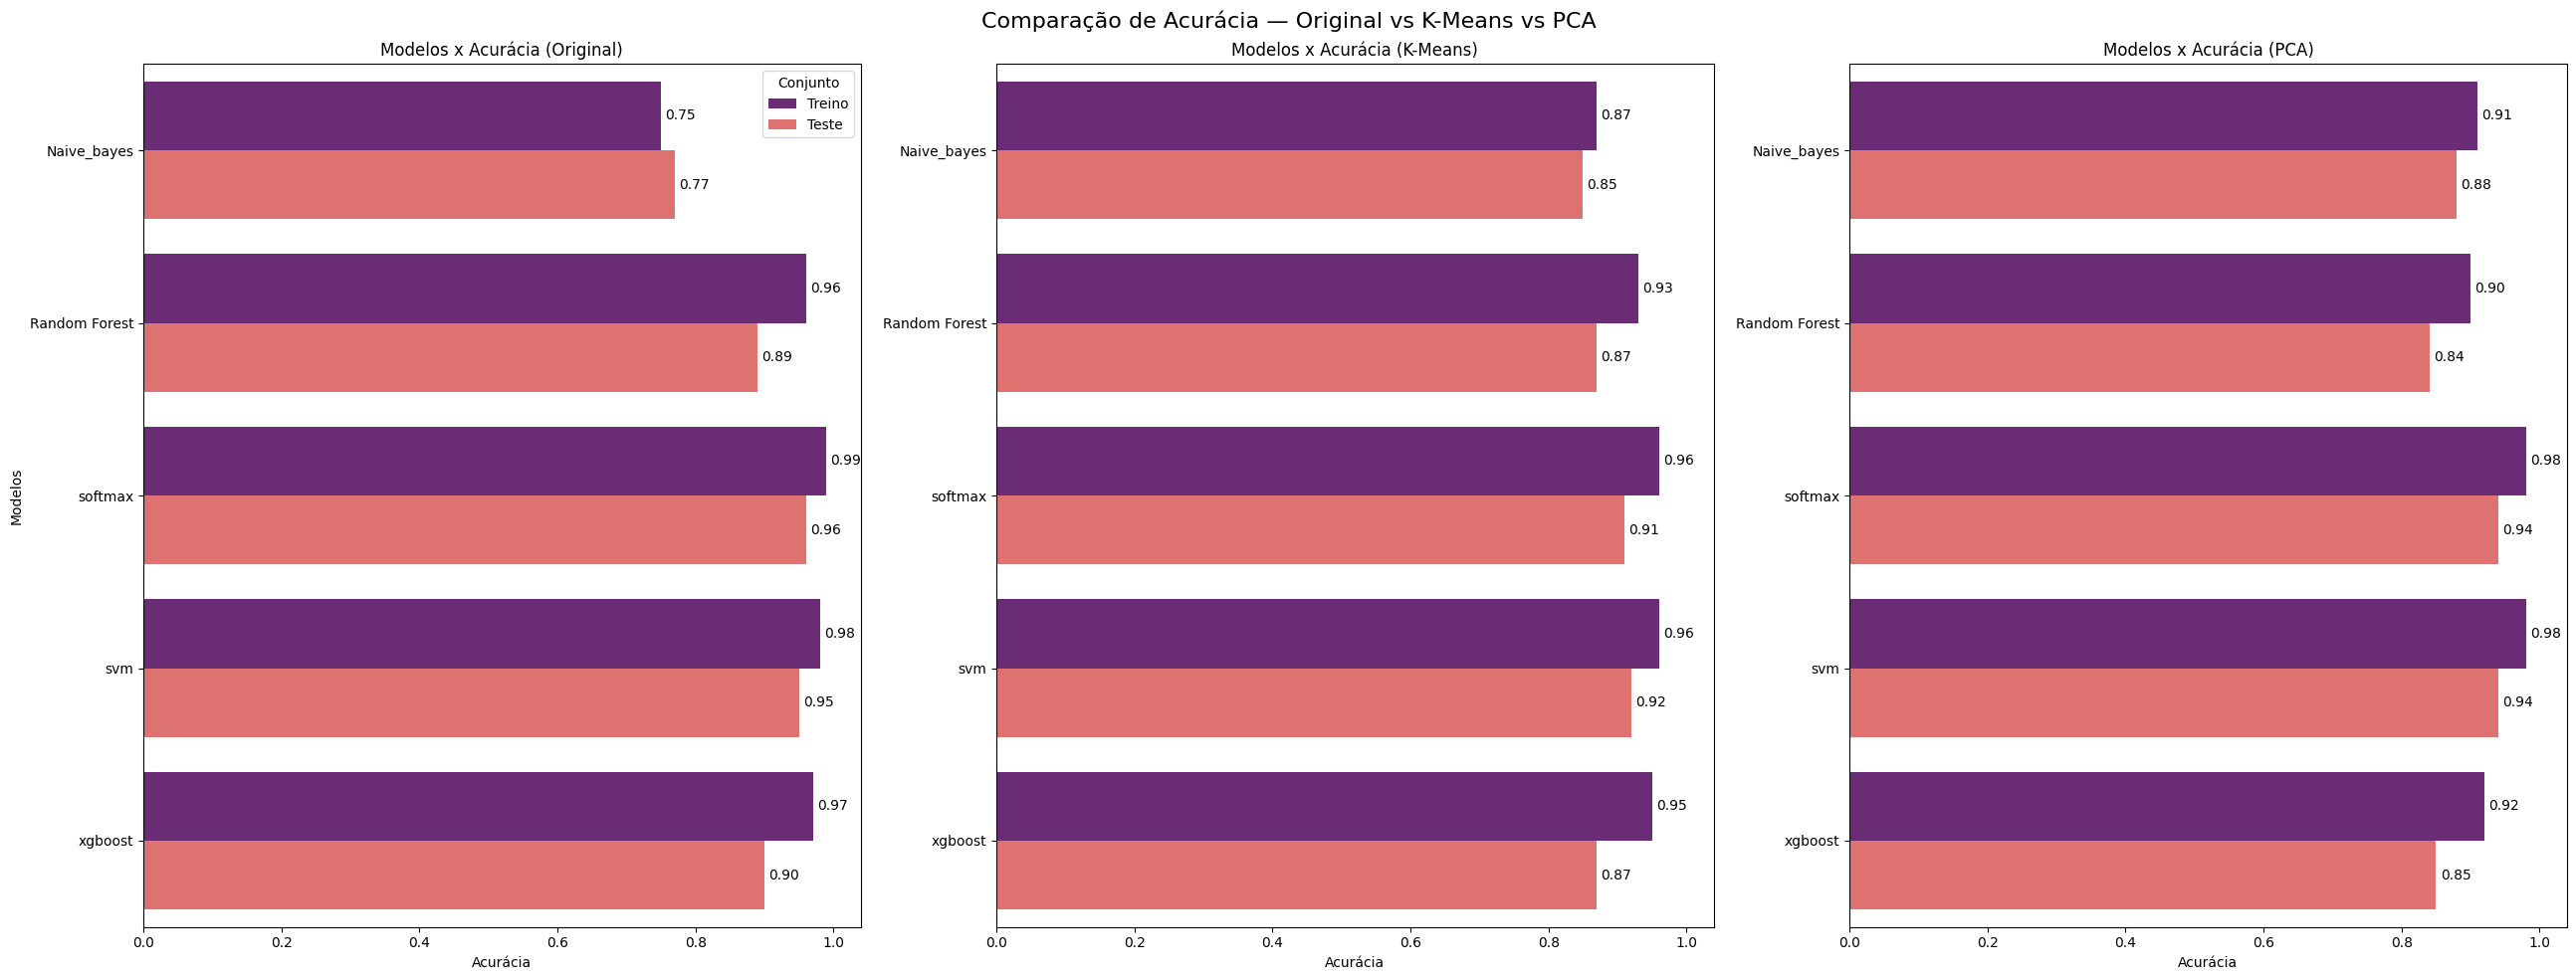

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(26, 10), sharex=True)

# =========================
# Gráfico 1 — Original
# =========================
df_treino_orig = pd.DataFrame({
    "Modelos": list(original_treino.keys()),
    "Acurácia": list(original_treino.values()),
    "Conjunto": "Treino"
})

df_teste_orig = pd.DataFrame({
    "Modelos": list(original_teste.keys()),
    "Acurácia": list(original_teste.values()),
    "Conjunto": "Teste"
})

df_orig = pd.concat([df_treino_orig, df_teste_orig], ignore_index=True)

ax1 = sns.barplot(
    data=df_orig,
    x="Acurácia",
    y="Modelos",
    hue="Conjunto",
    palette="magma",
    orient="h",
    ax=axes[0]
)

axes[0].set_title("Modelos x Acurácia (Original)")
axes[0].set_xlabel("Acurácia")
axes[0].set_ylabel("Modelos")

for container in ax1.containers:
    ax1.bar_label(container, fmt="%.2f", padding=3)

# =========================
# Gráfico 2 — K-Means
# =========================
df_treino_km = pd.DataFrame({
    "Modelos": list(k_means_treino.keys()),
    "Acurácia": list(k_means_treino.values()),
    "Conjunto": "Treino"
})

df_teste_km = pd.DataFrame({
    "Modelos": list(k_means_teste.keys()),
    "Acurácia": list(k_means_teste.values()),
    "Conjunto": "Teste"
})

df_km = pd.concat([df_treino_km, df_teste_km], ignore_index=True)

ax2 = sns.barplot(
    data=df_km,
    x="Acurácia",
    y="Modelos",
    hue="Conjunto",
    palette="magma",
    orient="h",
    ax=axes[1]
)

axes[1].set_title("Modelos x Acurácia (K-Means)")
axes[1].set_xlabel("Acurácia")
axes[1].set_ylabel("")

for container in ax2.containers:
    ax2.bar_label(container, fmt="%.2f", padding=3)

axes[1].legend_.remove()  # evita legenda duplicada

# =========================
# Gráfico 3 — PCA
# =========================
df_treino_pca = pd.DataFrame({
    "Modelos": list(pca_treino.keys()),
    "Acurácia": list(pca_treino.values()),
    "Conjunto": "Treino"
})

df_teste_pca = pd.DataFrame({
    "Modelos": list(pca_teste.keys()),
    "Acurácia": list(pca_teste.values()),
    "Conjunto": "Teste"
})

df_pca = pd.concat([df_treino_pca, df_teste_pca], ignore_index=True)

ax3 = sns.barplot(
    data=df_pca,
    x="Acurácia",
    y="Modelos",
    hue="Conjunto",
    palette="magma",
    orient="h",
    ax=axes[2]
)

axes[2].set_title("Modelos x Acurácia (PCA)")
axes[2].set_xlabel("Acurácia")
axes[2].set_ylabel("")

for container in ax3.containers:
    ax3.bar_label(container, fmt="%.2f", padding=3)

axes[2].legend_.remove()  # evita legenda duplicada

# Ajustes finais
plt.suptitle("Comparação de Acurácia — Original vs K-Means vs PCA", fontsize=16)
plt.tight_layout()
plt.show()

**Investigando melhor o motivo das métricas da classe 6(Laying) estar tão boa em todos os modelos em todos os métodos que estamos desenvolvendo**

## Referências

1. Ismi, Dewi Pramudi et al. “K-means clustering based filter feature selection on high dimensional data.” International Journal of Advances in Intelligent Informatics 2 (2016): 38-45.